In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
df=pd.read_csv("business_sales.csv")

In [8]:
df

,Date,Advertising_Expense,Discount_Percent,Customers,Sales
0,2021-01-01,21854.31,6.54,697,125968.48
1,2021-01-02,47782.14,6.17,100,122968.88
2,2021-01-03,37939.73,22.66,143,112651.77
3,2021-01-04,31939.63,6.24,244,85786.51
4,2021-01-05,12020.84,6.80,106,57146.45
...,...,...,...,...,...
1995,2026-06-19,34562.98,11.05,337,116403.05
1996,2026-06-20,48047.66,8.36,609,162208.36
1997,2026-06-21,8103.11,9.86,766,91594.38
1998,2026-06-22,7567.46,13.25,308,44135.18


In [9]:
df.head()

,Date,Advertising_Expense,Discount_Percent,Customers,Sales
0,2021-01-01,21854.31,6.54,697,125968.48
1,2021-01-02,47782.14,6.17,100,122968.88
2,2021-01-03,37939.73,22.66,143,112651.77
3,2021-01-04,31939.63,6.24,244,85786.51
4,2021-01-05,12020.84,6.80,106,57146.45


In [10]:
df.shape

(2000, 5)

In [11]:
df.isnull().sum()

Date                   0
Advertising_Expense    0
Discount_Percent       0
Customers              0
Sales                  0
dtype: int64

In [12]:
x=df[["Advertising_Expense","Discount_Percent","Customers"]]
y=df["Sales"]

In [14]:
X_train, X_test, y_train, y_test=train_test_split(
    x,y, test_size=0.2, random_state=42
)    

In [15]:
model=LinearRegression()

In [18]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
y_pred=model.predict(X_test)
y_pred

array([166882.98524356,  78055.61558154, 168740.94198373, 141764.77569105,
       109038.98829557,  32905.69195132,  54863.67963869, 124855.48156334,
       118401.63697012,  55888.22630489, 103578.31763414, 108902.18508368,
        99976.70480189,  99770.13666333,  51085.19424207, 145550.97877462,
        74793.8194736 ,  67447.76886901,  95269.01976434, 183255.21701948,
        76515.36741514, 133908.04607538, 168134.61348941, 142190.39016262,
       156315.72928336,  65745.9066861 ,  84851.61345935, 125613.5234603 ,
        94414.56337587,  76055.1488371 ,  33097.4500818 ,  60931.79756546,
        74284.51449656, 107439.67536674, 131249.74952265, 141220.44617944,
       142462.71675594,  99979.97619413,  89180.90315287,  68203.29460298,
        87984.78229984, 129162.73167338,  90034.53545895,  85101.21792781,
        93501.17329139, 150208.84568493, 148494.66044665, 117136.73541836,
       136048.1277603 ,  84696.56889759, 106803.83953625, 177301.24136493,
       150109.67693467, 1

In [21]:
result=pd.DataFrame({
    "Actual_Sales":y_test,
    "Predicted_Sales":y_pred
})    

In [22]:
print("\nActual_sales vs Predicted_sales")
print(result.head(10))


Actual_sales vs Predicted_sales
      Actual_Sales  Predicted_Sales
1860     163507.08    166882.985244
353       82966.61     78055.615582
1333     170527.79    168740.941984
905      141609.08    141764.775691
1289     118924.86    109038.988296
1273      32332.24     32905.691951
938       42551.16     54863.679639
1731     141713.85    124855.481563
65       133587.96    118401.636970
1323      46231.78     55888.226305


In [23]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("M. S. E : ", mse)
print("R2 score : ", r2)

M. S. E :  109483689.57319479
R2 score :  0.92235474312562


In [24]:
new_data = [[30000, 10, 500]]
future_sales = model.predict(new_data)

C:\Users\YAJNESH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
print("Predicted Sales:", future_sales[0])

Predicted Sales: 115804.39993738645


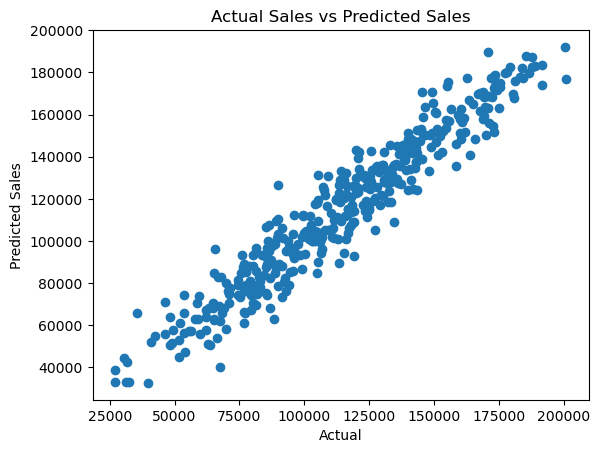

In [27]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs Predicted Sles")
plt.show()